In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("raw_metrics_wine_v2.json") as file:
    
    raw_wine = json.load(file)
    
with open("raw_metrics_iris_v2.json") as file:
    
    raw_iris = json.load(file)
    
with open("raw_metrics_bc_v2.json") as file:
    
    raw_bc = json.load(file)

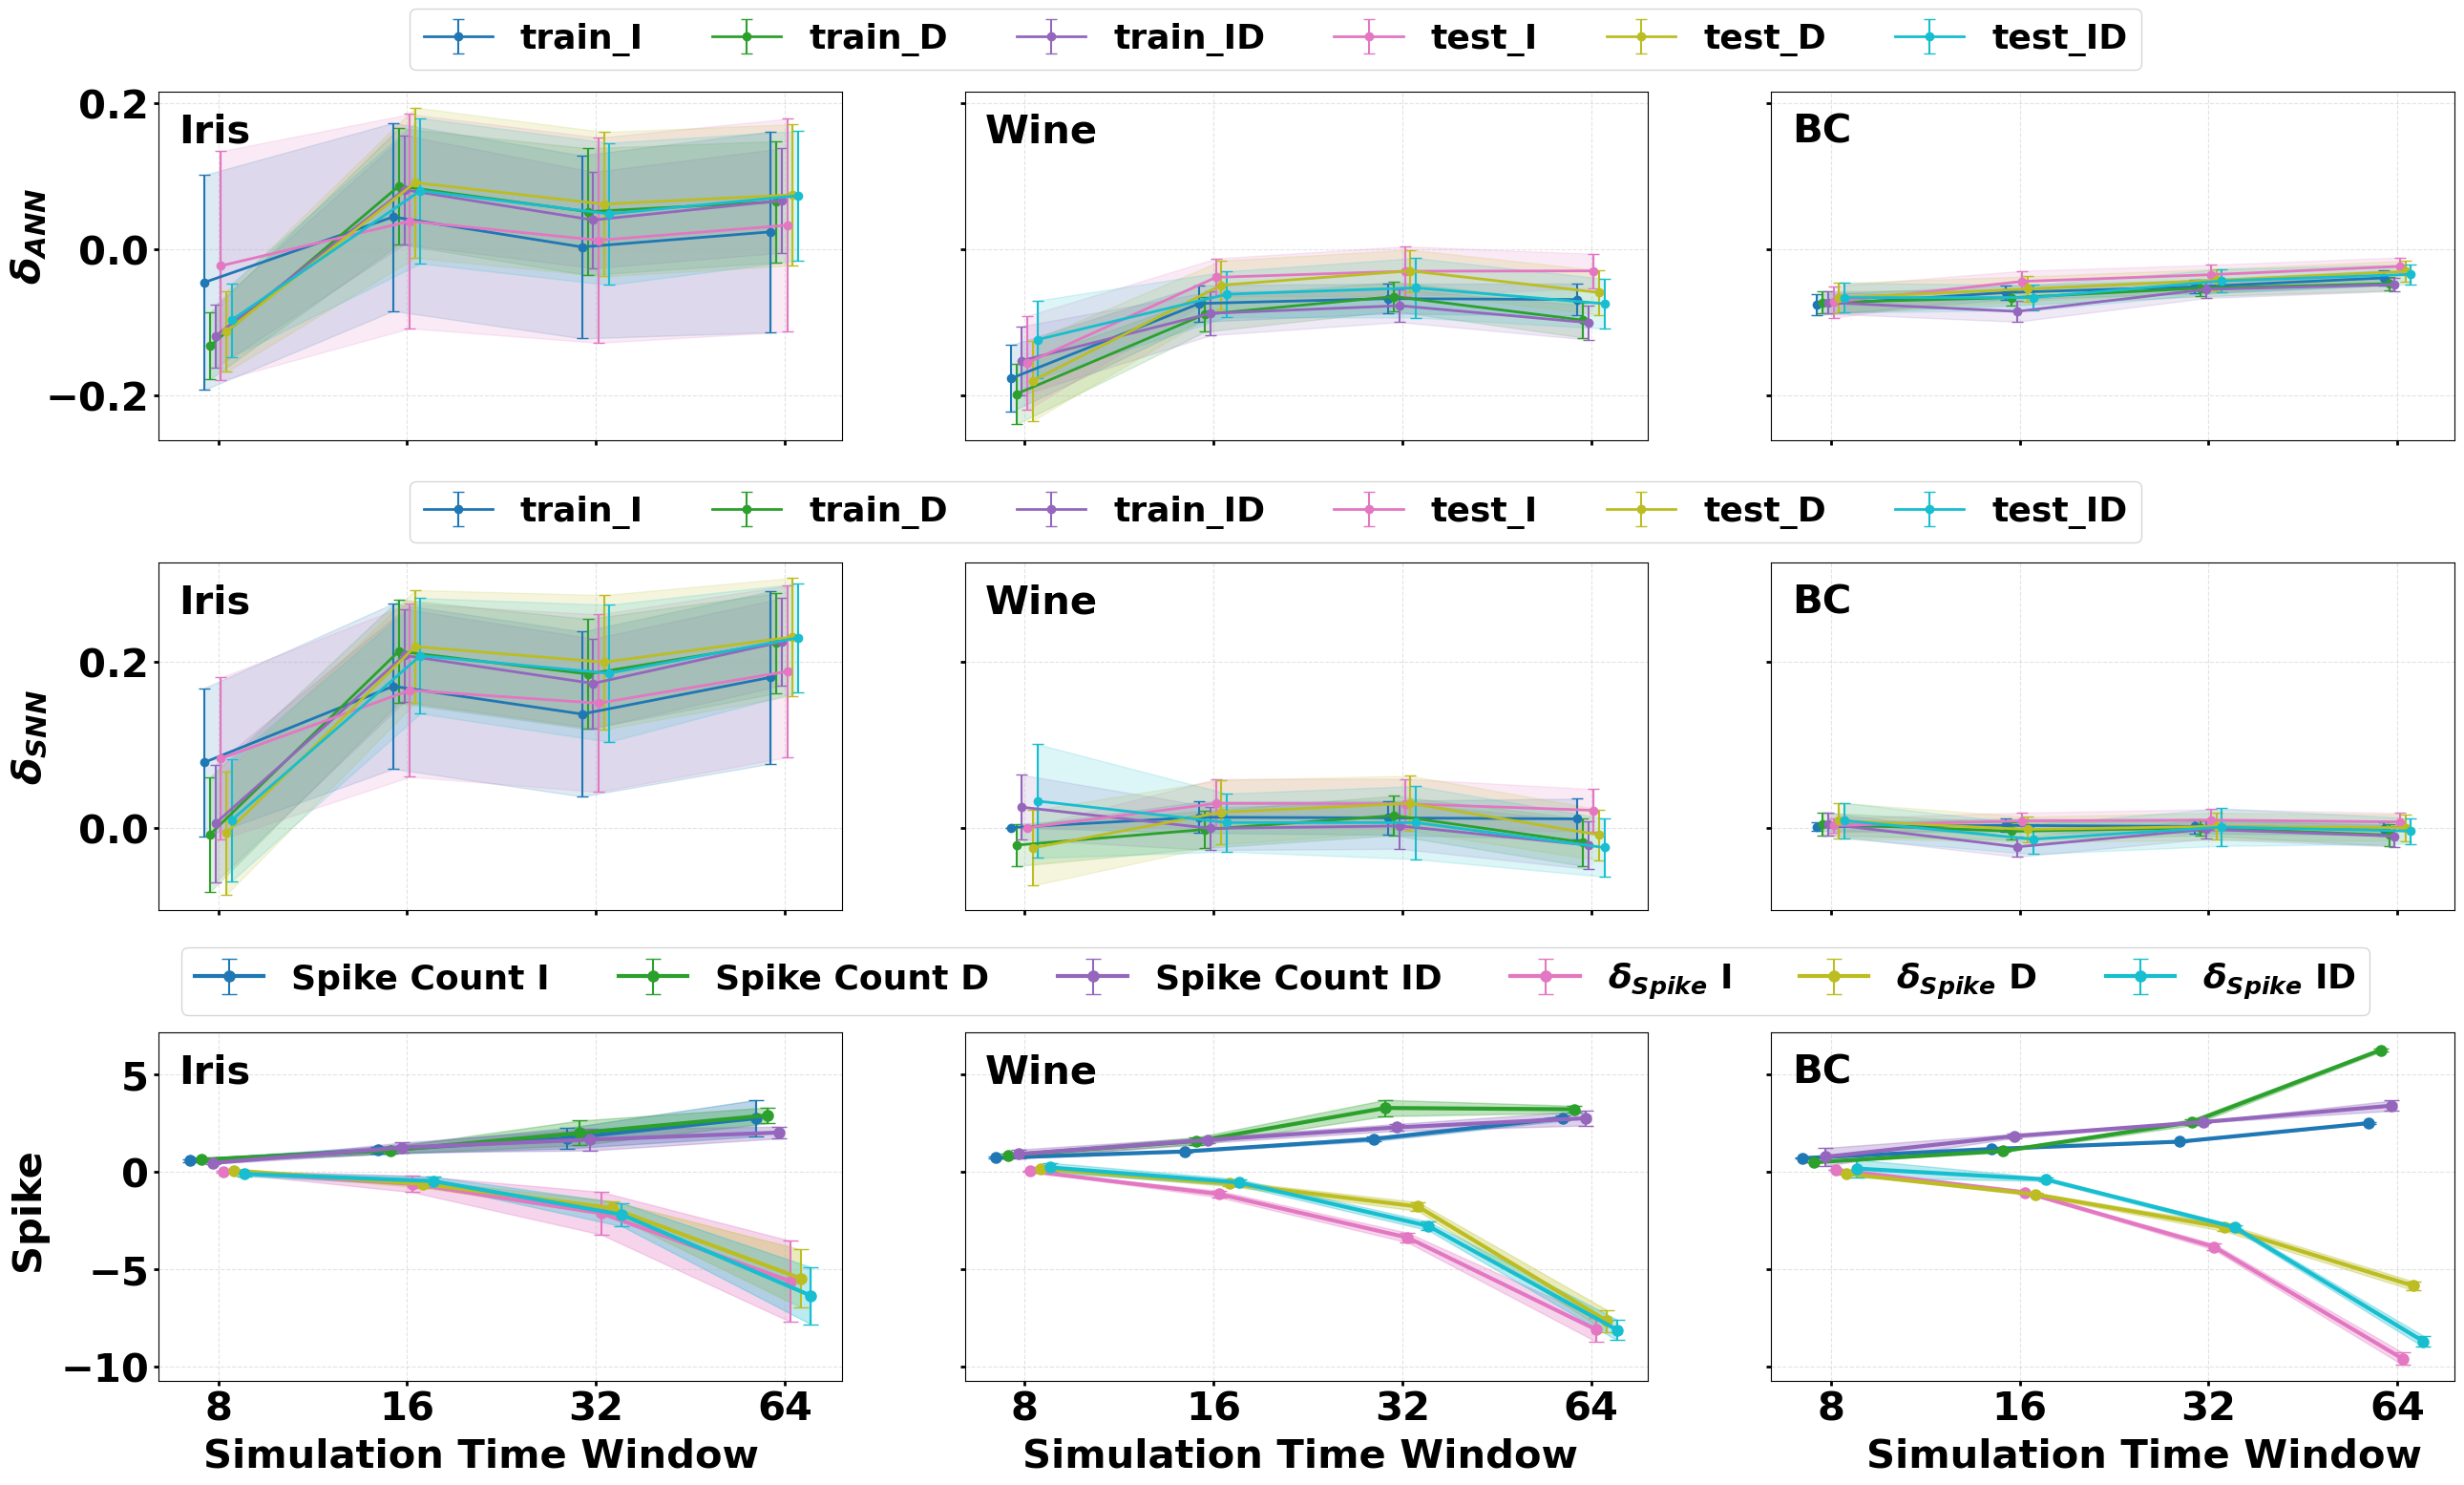

In [45]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ============================================================
# FONT SIZES (EDIT ONLY HERE)
# ============================================================
FS_TICK = 30          # xtick / ytick
FS_DATASET = 30       # "Iris/Wine/BC" inside each subplot
FS_GLOBAL_X = 30      # global x-label text (your 3 texts)
FS_ROW_LABEL = 30     # left-side row labels (delta_ANN, delta_SNN, Spike)
FS_LEGEND = 26        # legend font size

# Optional: if you ever add per-axis x/y labels
FS_XLABEL = 30
FS_YLABEL = 30

# ============================================================
# USER SETTINGS / INPUTS
# ============================================================
datasets = {
    "wine": "raw_metrics_wine_v2.json",
    "iris": "raw_metrics_iris_v2.json",
    "bc":   "raw_metrics_bc_v2.json"
}
f_samples = [8, 16, 32, 64]

drop_keys = [
    "train_drop_phase2", "train_drop_phase1", "train_drop_phase3",
    "test_drop_phase2",  "test_drop_phase1",  "test_drop_phase3",
]
gain_keys = [
    "train_gain_phase2", "train_gain_phase1", "train_gain_phase3",
    "test_gain_phase2",  "test_gain_phase1",  "test_gain_phase3",
]
drop_labels = ["train_I", "train_D", "train_ID", "test_I", "test_D", "test_ID"]
gain_labels = ["train_I", "train_D", "train_ID", "test_I", "test_D", "test_ID"]

phases = ['phase2', 'phase1', 'phase3', 'phase2_', 'phase1_', 'phase3_']
spike_keys = [f"spike_count_mean_{p}" for p in phases]
spike_labels = [
    'Spike Count I', 'Spike Count D', 'Spike Count ID',
    r'$\delta_{Spike}$ I', r'$\delta_{Spike}$ D', r'$\delta_{Spike}$ ID'
]

dataset_order = ["iris", "wine", "bc"]
dataset_title = {"iris": "Iris", "wine": "Wine", "bc": "BC"}

# ============================================================
# LOAD DROP/GAIN SUMMARIES
# ============================================================
def build_mean_std_summary_from_json(file_path, f_samples):
    with open(file_path, "r") as f:
        metrics = json.load(f)

    summary = {}
    for fs in f_samples:
        fs_key = str(fs)
        summary[fs_key] = {}
        for key, values in metrics[fs_key].items():
            if key.startswith("confusion"):
                continue
            arr = np.array(values, dtype=float)
            summary[fs_key][key] = {
                "mean": float(np.mean(arr)),
                "std":  float(np.std(arr))
            }
    return summary

summary_drop_gain = {name: build_mean_std_summary_from_json(fp, f_samples)
                     for name, fp in datasets.items()}

# ============================================================
# BUILD SPIKE SUMMARY (raw_iris/raw_wine/raw_bc must exist)
# ============================================================
def build_spike_summary(raw_train_test, f_samples, phases):
    summary = {}
    for method in phases:
        for fs in f_samples:
            fs_key = str(fs)
            summary.setdefault(fs_key, {})

            mean_train = np.array(raw_train_test[fs_key][f"mean_spike_train_{method}"])
            mean_test  = np.array(raw_train_test[fs_key][f"mean_spike_test_{method}"])

            weighted = mean_train * 0.70 + mean_test * 0.30
            summary[fs_key][f"spike_count_mean_{method}"] = {
                "mean": float(np.mean(weighted)),
                "std":  float(np.std(weighted))
            }
    return summary

summary_spike = {
    "iris": build_spike_summary(raw_iris, f_samples, phases),
    "wine": build_spike_summary(raw_wine, f_samples, phases),
    "bc":   build_spike_summary(raw_bc,   f_samples, phases),
}

# ============================================================
# GLOBAL STYLING (weights + tick defaults)
# ============================================================
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'xtick.labelsize': FS_TICK,
    'ytick.labelsize': FS_TICK,
    'xtick.major.width': 2,
    'ytick.major.width': 2,
})

# ============================================================
# PLOTTING HELPER
# ============================================================
def plot_metric_subplot(ax, summary, f_samples, metric_keys,
                        offset_width=0.05, line_width=2,
                        marker_size=6, cap_size=4,
                        fill_alpha=0.15, tick_fs=FS_TICK):
    num_keys = len(metric_keys)
    cmap = plt.cm.tab10(np.linspace(0, 1, num_keys))
    offsets = np.linspace(-offset_width, offset_width, num_keys)

    for i, key in enumerate(metric_keys):
        means, stds, valid_fs = [], [], []
        for fs in f_samples:
            d = summary.get(str(fs), {})
            if key in d:
                means.append(d[key]["mean"])
                stds.append(d[key]["std"])
                valid_fs.append(fs)
        if not means:
            continue

        means = np.array(means)
        stds  = np.array(stds)
        x_off = np.array(valid_fs) * (1 + offsets[i])
        color = cmap[i]

        ax.fill_between(x_off, means - stds, means + stds, color=color, alpha=fill_alpha)
        ax.errorbar(
            x_off, means, yerr=stds, fmt='o-', capsize=cap_size,
            elinewidth=1.5, linewidth=line_width, markersize=marker_size,
            color=color, label=key
        )

    ax.set_xscale('log', base=2)
    ax.set_xticks([8, 16, 32, 64])
    ax.set_xticklabels(['8', '16', '32', '64'])
    ax.grid(True, which='both', linestyle='--', alpha=0.35)
    ax.tick_params(axis='both', labelsize=tick_fs)
    ax.locator_params(axis='y', nbins=4)

# ============================================================
# BUILD COMBINED FIGURE (3x3)
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(26, 15), sharex=True)

# Share Y within each row only + hide redundant y tick labels
for r in range(3):
    for c in range(1, 3):
        axes[r, c].sharey(axes[r, 0])
        axes[r, c].tick_params(labelleft=False)

# Row 1: DROP
for j, ds in enumerate(dataset_order):
    plot_metric_subplot(
        axes[0, j], summary_drop_gain[ds], f_samples, drop_keys,
        offset_width=0.05, line_width=2, marker_size=6, cap_size=4, fill_alpha=0.15
    )

# Row 2: GAIN
for j, ds in enumerate(dataset_order):
    plot_metric_subplot(
        axes[1, j], summary_drop_gain[ds], f_samples, gain_keys,
        offset_width=0.05, line_width=2, marker_size=6, cap_size=4, fill_alpha=0.15
    )

# Row 3: SPIKE
for j, ds in enumerate(dataset_order):
    plot_metric_subplot(
        axes[2, j], summary_spike[ds], f_samples, spike_keys,
        offset_width=0.10, line_width=3, marker_size=8, cap_size=6, fill_alpha=0.30
    )

# Dataset labels inside each subplot
for i in range(3):
    for j, ds in enumerate(dataset_order):
        axes[i, j].text(
            0.03, 0.94, dataset_title[ds],
            transform=axes[i, j].transAxes,
            fontsize=FS_DATASET, fontweight='bold',
            va='top', ha='left'
        )

# Share x-axis: only bottom row shows x tick labels
for i in [0, 1]:
    for j in range(3):
        axes[i, j].tick_params(labelbottom=False)

# Global x labels (your three positions)
fig.text(0.2, -0.06, "Simulation Time Window", ha="center",
         fontsize=FS_GLOBAL_X, fontweight="bold")
fig.text(0.53, -0.06, "Simulation Time Window", ha="center",
         fontsize=FS_GLOBAL_X, fontweight="bold")
fig.text(0.87, -0.06, "Simulation Time Window", ha="center",
         fontsize=FS_GLOBAL_X, fontweight="bold")

# Row labels on the left
fig.text(0.01, 0.8, r"$\delta_{ANN}$", rotation=90, va="center",
         fontsize=FS_ROW_LABEL, fontweight="bold")
fig.text(0.01, 0.45, r"$\delta_{SNN}$", rotation=90, va="center",
         fontsize=FS_ROW_LABEL, fontweight="bold")
fig.text(0.01, 0.12, "Spike", rotation=90, va="center",
         fontsize=FS_ROW_LABEL, fontweight="bold")

# Reserve whitespace ABOVE the subplot grid
plt.subplots_adjust(left=0.07, right=0.995, top=0.90, bottom=0.00,
                    hspace=0.35, wspace=0.18)

# Legends (font size controlled by FS_LEGEND)
h0, _ = axes[0, 0].get_legend_handles_labels()
fig.legend(
    h0, drop_labels, ncol=6, frameon=True,
    loc="upper center",
    bbox_to_anchor=(0.52, 0.97),
    bbox_transform=fig.transFigure,
    prop=font_manager.FontProperties(weight='bold', size=FS_LEGEND)
)

h1, _ = axes[1, 0].get_legend_handles_labels()
fig.legend(
    h1, gain_labels, ncol=6, frameon=True,
    loc="upper center",
    bbox_to_anchor=(0.52, 0.64),
    bbox_transform=fig.transFigure,
    prop=font_manager.FontProperties(weight='bold', size=FS_LEGEND)
)

h2, _ = axes[2, 0].get_legend_handles_labels()
fig.legend(
    h2, spike_labels, ncol=6, frameon=True,
    loc="upper center",
    bbox_to_anchor=(0.52, 0.315),
    bbox_transform=fig.transFigure,
    prop=font_manager.FontProperties(weight='bold', size=FS_LEGEND)
)

plt.savefig("all_metrics_compact.pdf", bbox_inches="tight")
plt.show()